# Pratica 5 — Transformers and LLMs for Text Classification

This notebook has two parts:

- **Part 1** — Build and train a Transformer classifier on the **AG News** topic dataset
- **Part 2** — Use a large language model (LLaMA via Groq) for zero-shot and few-shot classification

**Dataset (Part 1):** AG News — ~120 000 train / 7 600 test, 4 topic classes:

| Label | Topic |
|---|---|
| 0 | World |
| 1 | Sports |
| 2 | Business |
| 3 | Sci/Tech |

**Dataset (Part 2):** same AG News, but we only send a handful of examples to the LLM API

---
# Part 1 — Transformer for Text Classification

## 1.1 Recap: the Transformer building blocks

In the theory class we saw the core building blocks (code in `transformer-ex.py`):

| Component | Role |
|---|---|
| **SelfAttention** | Scaled dot-product attention — one head |
| **MultiHeadAttention** | Several heads in parallel, outputs concatenated + linear projection |
| **FeedForward** | Two-layer MLP inside each block |
| **TransformerBlock** | Attention → residual+norm → FF → residual+norm |
| **PositionalEncoding** | Adds positional signal to embeddings (sin/cos) |

For classification we only need the **encoder** part: the input is a sequence of token embeddings + positional encoding, fed through stacked Transformer blocks.  
The sequence is then **pooled** (mean over positions) and passed to a linear classifier.

```
token ids → Embedding + PosEmb → TransformerBlock × N → mean pool → Linear(num_classes)
```

## 1.2 Imports and device

In [1]:
import re
import numpy as np
import torch
import torch.nn as nn
from collections import Counter
from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## 1.3 Data loading and preprocessing

AG News stores each sample as a dict with `text` and `label` (0–3).  
We reuse the same pipeline as in Pratica 4: clean text → build vocabulary → integer-encode → pad/truncate.

In [2]:
# ── text helpers ──────────────────────────────────────────────────────────────

def clean_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    return text

def build_vocab(texts, max_words=10000):
    counter = Counter()
    for text in texts:
        counter.update(clean_text(text).split())
    most_common = counter.most_common(max_words - 2)
    word_index = {"<pad>": 0, "<unk>": 1}
    for i, (word, _) in enumerate(most_common, start=2):
        word_index[word] = i
    return word_index

def encode(text, word_index, max_len=128):
    tokens = clean_text(text).split()
    seq = [word_index.get(w, 1) for w in tokens][:max_len]
    seq += [0] * (max_len - len(seq))
    return torch.tensor(seq, dtype=torch.long)

# ── Dataset ───────────────────────────────────────────────────────────────────

class AGNewsDataset(Dataset):
    def __init__(self, texts, labels, word_index, max_len=128):
        self.texts = texts
        self.labels = labels
        self.word_index = word_index
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        x = encode(self.texts[idx], self.word_index, self.max_len)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y

# ── Loaders ───────────────────────────────────────────────────────────────────

def get_loaders(max_words=10000, max_len=128, batch_size=256, val_split=0.9):
    ds = load_dataset("ag_news")
    train_texts  = ds["train"]["text"]
    train_labels = np.array(ds["train"]["label"], dtype=np.int64)
    test_texts   = ds["test"]["text"]
    test_labels  = np.array(ds["test"]["label"],  dtype=np.int64)

    word_index = build_vocab(train_texts, max_words)

    full_train = AGNewsDataset(train_texts, train_labels, word_index, max_len)
    test_ds    = AGNewsDataset(test_texts,  test_labels,  word_index, max_len)

    n_train = int(val_split * len(full_train))
    train_ds, val_ds = random_split(full_train, [n_train, len(full_train) - n_train],
                                    generator=torch.Generator().manual_seed(42))

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size)
    return train_loader, val_loader, test_loader, word_index

MAX_WORDS   = 10000
MAX_LEN     = 128
BATCH       = 256
NUM_CLASSES = 4

train_loader, val_loader, test_loader, word_index = get_loaders(MAX_WORDS, MAX_LEN, BATCH)
print(f"Vocab size: {len(word_index)}")
print(f"Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

Vocab size: 10000
Train batches: 422 | Val: 47 | Test: 30


## 1.4 Transformer classifier

We use PyTorch's built-in `nn.TransformerEncoderLayer` / `nn.TransformerEncoder`.  
**Learned positional embeddings** replace the sinusoidal encoding.

The only structural change from binary (IMDb) to 4-class (AG News) is the output size of the final linear layer.

In [3]:
class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, num_heads=4, ff_dim=256,
                 max_len=128, num_layers=2, dropout=0.1, num_classes=4):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.pos_emb   = nn.Embedding(max_len, embed_dim)   # learned positional embeddings

        encoder_layer    = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=ff_dim, dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.classifier  = nn.Linear(embed_dim, num_classes)
        self.dropout     = nn.Dropout(dropout)

    def forward(self, x):
        B, L = x.shape
        positions = torch.arange(L, device=x.device).unsqueeze(0).expand(B, L)
        x = self.dropout(self.token_emb(x) + self.pos_emb(positions))  # (B, L, D)
        x = self.transformer(x)                                          # (B, L, D)
        x = x.mean(dim=1)                                                # mean pool → (B, D)
        return self.classifier(x)                                        # (B, num_classes)

model = TransformerClassifier(vocab_size=MAX_WORDS, embed_dim=128, num_heads=4,
                               ff_dim=256, max_len=MAX_LEN, num_layers=2,
                               num_classes=NUM_CLASSES).to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {total_params:,}")

TransformerClassifier(
  (token_emb): Embedding(10000, 128, padding_idx=0)
  (pos_emb): Embedding(128, 128)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (classifier): Linear(in_features=128, out_features=4, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
)

Trainable parameters: 1,561,860


## 1.5 Training

> **Note:** For 4-class classification we use **`CrossEntropyLoss`** (instead of `BCEWithLogitsLoss` which is for binary).  
> The model outputs a vector of `num_classes` logits; the predicted class is the one with the highest logit.

In [12]:
def train_model(model, train_loader, val_loader, epochs=10, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train_acc": [], "val_acc": [], "train_loss": [], "val_loss": []}

    for epoch in range(epochs):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()

        tr_loss, tr_acc = evaluate(model, train_loader, criterion)
        va_loss, va_acc = evaluate(model, val_loader,   criterion)
        history["train_acc"].append(tr_acc);  history["train_loss"].append(tr_loss)
        history["val_acc"].append(va_acc);    history["val_loss"].append(va_loss)
        print(f"Epoch {epoch+1}/{epochs}  train acc={tr_acc:.4f}  val acc={va_acc:.4f}")

    return history

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            total_loss += criterion(out, y).item()
            correct += (out.argmax(dim=1) == y).sum().item()
            total   += y.size(0)
    return total_loss / len(loader), correct / total

history = train_model(model, train_loader, val_loader, epochs=10, lr=1e-4)

Epoch 1/10  train acc=0.9102  val acc=0.8843
Epoch 2/10  train acc=0.9113  val acc=0.8857
Epoch 3/10  train acc=0.9121  val acc=0.8857
Epoch 4/10  train acc=0.9126  val acc=0.8859
Epoch 5/10  train acc=0.9133  val acc=0.8859
Epoch 6/10  train acc=0.9137  val acc=0.8867
Epoch 7/10  train acc=0.9140  val acc=0.8874
Epoch 8/10  train acc=0.9147  val acc=0.8882
Epoch 9/10  train acc=0.9147  val acc=0.8873
Epoch 10/10  train acc=0.9150  val acc=0.8889


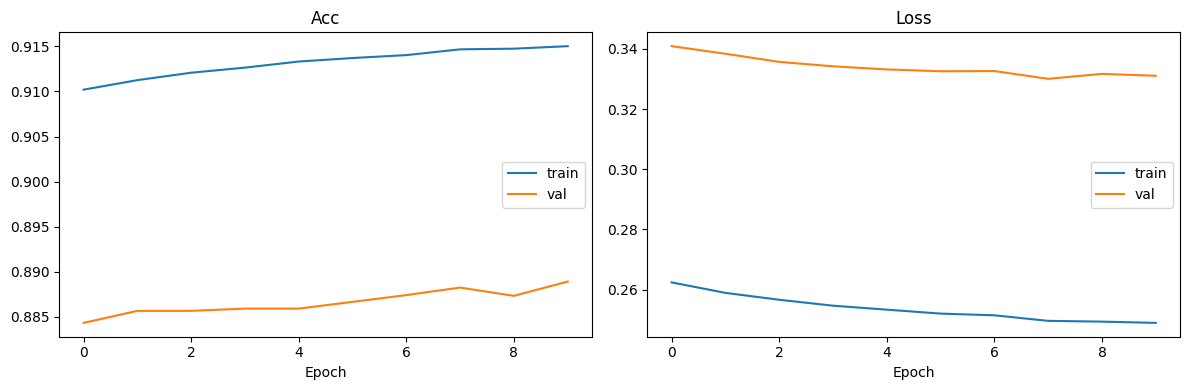


Test accuracy: 0.8900


In [13]:
# ── learning curves ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric in zip(axes, ["acc", "loss"]):
    ax.plot(history[f"train_{metric}"], label="train")
    ax.plot(history[f"val_{metric}"],   label="val")
    ax.set_title(metric.capitalize())
    ax.set_xlabel("Epoch")
    ax.legend()
plt.tight_layout()
plt.show()

_, test_acc = evaluate(model, test_loader, nn.CrossEntropyLoss())
print(f"\nTest accuracy: {test_acc:.4f}")

---
# Part 2 — Zero-shot and Few-shot with an LLM

Instead of training a model, we **prompt** a large pretrained language model to classify text — no gradient descent needed.

We use the **Groq API** (free tier) with **LLaMA 3.3 70B**.  
Install: `pip install groq`  
Get a key at https://console.groq.com

| Strategy | Labelled examples in prompt | Weight updates |
|---|---|---|
| **Zero-shot** | 0 | None |
| **Few-shot** | K (e.g. 3) | None |

## 2.1 Setup

Get a free API key at https://console.groq.com and paste it below.

In [6]:
%pip install groq

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from groq import Groq
import random

GROQ_API_KEY = "your-api-key-here"   # ← replace with your key

SEED = 42
random.seed(SEED)

N_TEST            = 20   # samples to classify
N_TRAIN_PER_CLASS =  2   # demonstrations per class → 8 total (balanced)

LABEL_NAMES = ["World", "Sports", "Business", "Sci/Tech"]

# Load AG News
raw = load_dataset("ag_news")

# Balanced demonstrations: N_TRAIN_PER_CLASS examples from each class
train_data = []
for label_id in range(4):
    subset = [s for s in raw["train"] if s["label"] == label_id]
    random.shuffle(subset)
    train_data.extend(subset[:N_TRAIN_PER_CLASS])
random.shuffle(train_data)

N_TRAIN = len(train_data)   # = 8

test_data = raw["test"].shuffle(seed=SEED).select(range(N_TEST))

print(f"Train examples (demonstrations): {N_TRAIN}  ({N_TRAIN_PER_CLASS} per class)")
print(f"Test examples to classify:       {len(test_data)}")

Train examples (demonstrations): 8  (2 per class)
Test examples to classify:       20


In [66]:
def call_llm(prompt: str, model="llama-3.3-70b-versatile") -> str:
    client = Groq(api_key=GROQ_API_KEY)
    resp = client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        max_tokens=512,
    )
    return resp.choices[0].message.content

## 2.2 Zero-shot classification

We describe the task in the prompt without providing any labelled examples.  
The LLM relies entirely on knowledge acquired during pre-training.

The 4 classes are: **0 = World, 1 = Sports, 2 = Business, 3 = Sci/Tech**.

In [67]:
import re as _re

def accuracy(preds, targets):
    correct = sum(p == t for p, t in zip(preds, targets))
    return correct / len(targets)

def report(label, preds, targets):
    print(f"Predicted    ({len(preds)}): {preds}")
    print(f"Ground truth ({len(targets)}): {targets}")
    if -1 in preds:
        print(f"⚠ {preds.count(-1)} unparseable response(s) counted as wrong")
    print(f"{label} accuracy: {accuracy(preds, targets):.2%}")

In [68]:
import re as _re
def build_zero_shot_prompt(article):
    """Build a prompt for a single article."""
    prompt  = "Classify the following news article into exactly one of these 4 categories:\n"
    prompt += "  0 = World (international/political news)\n"
    prompt += "  1 = Sports (any sport)\n"
    prompt += "  2 = Business (economy, markets, companies)\n"
    prompt += "  3 = Sci/Tech (science, technology, computing)\n\n"
    prompt += f"Article: {article['text'][:400]}\n\n"
    prompt += "Output ONLY a single integer (0, 1, 2, or 3)."
    return prompt

# Classify each test sample individually
zs_preds = []
for sample in test_data:
    prompt   = build_zero_shot_prompt(sample)
    response = call_llm(prompt)
    # parse the single integer from the response
    match = _re.search(r"\b([0-3])\b", response.strip())
    zs_preds.append(int(match.group(1)) if match else -1)
    print(f"  → {zs_preds[-1]}  (gt={sample['label']}  raw='{response.strip()[:30]}')")

print(f"\nZero-shot prompt example (first call):\n{build_zero_shot_prompt(test_data[0])}")

  → 1  (gt=1  raw='1')
  → 2  (gt=2  raw='2')
  → 1  (gt=1  raw='1')
  → 2  (gt=2  raw='2')
  → 3  (gt=3  raw='3')
  → 2  (gt=0  raw='2')
  → 2  (gt=2  raw='2')
  → 2  (gt=2  raw='2')
  → 3  (gt=3  raw='3')
  → 2  (gt=2  raw='2')
  → 2  (gt=0  raw='2')
  → 1  (gt=1  raw='1')
  → 1  (gt=1  raw='1')
  → 0  (gt=0  raw='0')
  → 2  (gt=2  raw='2')
  → 3  (gt=3  raw='3')
  → 0  (gt=0  raw='0')
  → 1  (gt=1  raw='1')
  → 0  (gt=0  raw='0')
  → 3  (gt=3  raw='3')

Zero-shot prompt example (first call):
Classify the following news article into exactly one of these 4 categories:
  0 = World (international/political news)
  1 = Sports (any sport)
  2 = Business (economy, markets, companies)
  3 = Sci/Tech (science, technology, computing)

Article: Indian board plans own telecast of Australia series The Indian cricket board said on Wednesday it was making arrangements on its own to broadcast next month #39;s test series against Australia, which is under threat because of a raging TV rights dispute

In [69]:
true_labels = [s["label"] for s in test_data]
report("Zero-shot", zs_preds, true_labels)

Predicted    (20): [1, 2, 1, 2, 3, 2, 2, 2, 3, 2, 2, 1, 1, 0, 2, 3, 0, 1, 0, 3]
Ground truth (20): [1, 2, 1, 2, 3, 0, 2, 2, 3, 2, 0, 1, 1, 0, 2, 3, 0, 1, 0, 3]
Zero-shot accuracy: 90.00%


## 2.3 Few-shot classification

We now add a few labelled examples at the beginning of the prompt.  
This is **in-context learning** — the model adapts its behaviour without updating any weights.

In [70]:
def build_few_shot_prompt(train_data, article):
    """Build a few-shot prompt for a single article."""
    prompt  = "Classify the following news article into exactly one of these 4 categories:\n"
    prompt += "  0 = World (international/political news)\n"
    prompt += "  1 = Sports (any sport)\n"
    prompt += "  2 = Business (economy, markets, companies)\n"
    prompt += "  3 = Sci/Tech (science, technology, computing)\n\n"
    prompt += "Here are some labelled examples:\n\n"
    for sample in train_data:
        label_name = LABEL_NAMES[sample["label"]]
        prompt += f"Article: {sample['text'][:200]}\nLabel: {sample['label']} ({label_name})\n\n"
    prompt += "--------\n"
    prompt += f"Article: {article['text'][:400]}\n\n"
    prompt += "Output ONLY a single integer (0, 1, 2, or 3)."
    return prompt

# Classify each test sample individually
fs_preds = []
for sample in test_data:
    prompt   = build_few_shot_prompt(train_data, sample)
    response = call_llm(prompt)
    match = _re.search(r"\b([0-3])\b", response.strip())
    fs_preds.append(int(match.group(1)) if match else -1)
    print(f"  → {fs_preds[-1]}  (gt={sample['label']}  raw='{response.strip()[:30]}')")

  → 1  (gt=1  raw='1')
  → 2  (gt=2  raw='2')
  → 1  (gt=1  raw='1')
  → 2  (gt=2  raw='2')
  → 3  (gt=3  raw='3')
  → 2  (gt=0  raw='2')
  → 2  (gt=2  raw='2')
  → 2  (gt=2  raw='2')
  → 3  (gt=3  raw='3')
  → 2  (gt=2  raw='2')
  → 2  (gt=0  raw='2')
  → 1  (gt=1  raw='1')
  → 1  (gt=1  raw='1')
  → 0  (gt=0  raw='0')
  → 2  (gt=2  raw='2')
  → 3  (gt=3  raw='3')
  → 0  (gt=0  raw='0')
  → 1  (gt=1  raw='1')
  → 0  (gt=0  raw='0')
  → 3  (gt=3  raw='3')


In [71]:
report(f"Few-shot ({N_TRAIN} demos)", fs_preds, true_labels)

Predicted    (20): [1, 2, 1, 2, 3, 2, 2, 2, 3, 2, 2, 1, 1, 0, 2, 3, 0, 1, 0, 3]
Ground truth (20): [1, 2, 1, 2, 3, 0, 2, 2, 3, 2, 0, 1, 1, 0, 2, 3, 0, 1, 0, 3]
Few-shot (8 demos) accuracy: 90.00%
